In [1]:
import time
from html import escape

from IPython.display import display
import matplotlib as mpl
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib_inline
import numpy as np
from scipy.ndimage import label
from scipy.optimize import brentq
from scipy.sparse import diags, eye, kron
from scipy.sparse.linalg import splu
from scipy.special import logsumexp, ndtr

matplotlib_inline.backend_inline.set_matplotlib_formats("svg", "pdf")


In [2]:
# BOOK_FIGURE_STYLE_CELL
FIGURE_SIZES = {
    "full_landscape": (4.50, 2.75),
    "full_standard": (4.50, 3.25),
    "full_tall": (4.50, 4.80),
    "half_standard": (2.15, 1.75),
}

mpl.rcParams.update(
    {
        "figure.figsize": FIGURE_SIZES["half_standard"],
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
        "axes.labelsize": 9,
        "axes.titlesize": 9,
        "axes.linewidth": 0.8,
        "axes.grid": False,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "legend.fontsize": 7,
        "legend.frameon": False,
        "lines.linewidth": 1.5,
        "lines.markersize": 4,
        "patch.linewidth": 0.8,
    }
)


def new_figure(size="half_standard", nrows=1, ncols=1, **kwargs):
    return plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=FIGURE_SIZES[size],
        constrained_layout=True,
        squeeze=kwargs.pop("squeeze", True),
        **kwargs,
    )


def label_panels(axes, *, boxed=False):
    for index, axis in enumerate(np.atleast_1d(axes).ravel()):
        text_options = {}
        if boxed:
            text_options["bbox"] = {
                "facecolor": "white",
                "edgecolor": "none",
                "alpha": 0.85,
                "pad": 1.0,
            }
        axis.text(
            0.02,
            0.98,
            f"({chr(97 + index)})",
            transform=axis.transAxes,
            fontsize=9,
            fontweight="bold",
            va="top",
            ha="left",
            **text_options,
        )


def finalize_axes(axes, *, keep_box=False):
    for axis in np.atleast_1d(axes).ravel():
        axis.grid(False)
        axis.spines["top"].set_visible(keep_box)
        axis.spines["right"].set_visible(keep_box)


def latex_escape(value):
    return (
        str(value)
        .replace("\\", r"\textbackslash{}")
        .replace("%", r"\%")
        .replace("_", r"\_")
        .replace("&", r"\&")
    )


def display_book_table(headers, rows, *, column_spec=None):
    widths = [len(str(header)) for header in headers]
    for row in rows:
        widths = [
            max(width, len(str(value)))
            for width, value in zip(widths, row)
        ]
    plain_lines = [
        "  ".join(str(value).ljust(width) for value, width in zip(headers, widths)),
        "  ".join("-" * width for width in widths),
    ]
    plain_lines.extend(
        "  ".join(str(value).ljust(width) for value, width in zip(row, widths))
        for row in rows
    )

    html_header = "".join(f"<th>{escape(str(value))}</th>" for value in headers)
    html_rows = "".join(
        "<tr>" + "".join(f"<td>{escape(str(value))}</td>" for value in row) + "</tr>"
        for row in rows
    )

    if column_spec is None:
        column_spec = "l" + "r" * (len(headers) - 1)
    latex_headers = [rf"\text{{{latex_escape(value)}}}" for value in headers]
    latex_rows = [
        [rf"\text{{{latex_escape(value)}}}" for value in row]
        for row in rows
    ]
    latex = (
        rf"\begin{{array}}{{{column_spec}}}\hline "
        + " & ".join(latex_headers)
        + r" \\ \hline "
        + r" \\ ".join(" & ".join(row) for row in latex_rows)
        + r" \\ \hline\end{array}"
    )

    display(
        {
            "text/plain": "\n".join(plain_lines),
            "text/html": (
                '<table class="table table-sm"><thead><tr>'
                + html_header
                + "</tr></thead><tbody>"
                + html_rows
                + "</tbody></table>"
            ),
            "text/latex": latex,
        },
        raw=True,
    )


# Inferring the Location of a Contaminant


The thermal example inferred a coefficient that changed the differential operator. The present example keeps the operator fixed and infers the center of a localized source. It also shows how a symmetry in the complete parameter-to-data map can create an exactly multimodal posterior.

## Steady source-localization model

Let $D=(0,1)^2$ be a nondimensional square. A continuously maintained source has reached a steady diffusive state $u_{\boldsymbol{\theta}}:D\to\mathbb{R}$ satisfying

$$
-\Delta u_{\boldsymbol{\theta}}(\mathbf{x})
=s_{\boldsymbol{\theta}}(\mathbf{x})
\quad\text{in }D,
\qquad
u_{\boldsymbol{\theta}}(\mathbf{x})=0
\quad\text{on }\partial D.
$$

The zero boundary value represents an idealized absorbing boundary. The unknown parameter

$$
\boldsymbol{\theta}=(\theta_1,\theta_2)\in
\Theta=[0.15,0.85]^2
$$

is the source center. The source has known total strength $Q=1$ and known width $\ell=0.06$. Let $\Phi_{\mathcal N}$ denote the standard normal cumulative distribution function and define

$$
c(a)=
\Phi_{\mathcal N}\!\left(\frac{1-a}{\ell}\right)
-\Phi_{\mathcal N}\!\left(-\frac{a}{\ell}\right).
$$

The normalized Gaussian source is

$$
s_{\boldsymbol{\theta}}(\mathbf{x})
=\frac{Q}{2\pi\ell^2 c(\theta_1)c(\theta_2)}
\exp\!\left[
-\frac{\|\mathbf{x}-\boldsymbol{\theta}\|_2^2}{2\ell^2}
\right].
$$

Consequently, $\int_D s_{\boldsymbol{\theta}}(\mathbf{x})\,d\mathbf{x}=Q$ for every admissible center. Only $\boldsymbol{\theta}$ is inferred; the PDE, boundary condition, $Q$, and $\ell$ are treated as known. This deliberately simple model isolates source localization and sensor geometry from the transient advection, uncertain media, and distributed sources that arise in field-scale contaminant inversion {cite:p}`michalak2003contaminant,alexanderian2021optimal`.


## Finite-difference observation map

Let $N$ be the number of equal segments along each coordinate, let $h=1/N$, and let $u_{ij}$ approximate the state at the interior node $(ih,jh)$ for $i,j=1,\ldots,N-1$. The five-point discretization is

$$
\frac{4u_{ij}-u_{i-1,j}-u_{i+1,j}-u_{i,j-1}-u_{i,j+1}}{h^2}
=s_{\boldsymbol{\theta}}(ih,jh),
$$

with zero values at boundary nodes. In matrix form,

$$
\mathbf{A}_h\mathbf{u}_h(\boldsymbol{\theta})
=\mathbf{s}_h(\boldsymbol{\theta}).
$$

For a sensor layout $d$, let $\mathbf{E}_d$ select the state values at its $m$ sensor locations. Its parameter-to-data map is

$$
\mathbf{G}_{h,d}(\boldsymbol{\theta})
=\mathbf{E}_d\mathbf{A}_h^{-1}
\mathbf{s}_h(\boldsymbol{\theta})\in\mathbb{R}^m.
$$

The matrix $\mathbf{A}_h$ is fixed while the source changes. Let $\mathbf{e}_j$ be the coordinate vector that selects the $j$th sensor degree of freedom, and solve the adjoint system $\mathbf{A}_h^{\mathsf{T}}\mathbf{z}_j=\mathbf{e}_j$ once. Every later prediction is the inner product $G_{h,d,j}(\boldsymbol{\theta})=\mathbf{z}_j^{\mathsf{T}}\mathbf{s}_h(\boldsymbol{\theta})$. The implementation therefore uses one sparse factorization and one adjoint right-hand side per sensor instead of a PDE solve at every candidate location. Sparse construction and factorization use SciPy {cite:p}`virtanen2020scipy`.


In [3]:
def build_poisson_solver(num_segments):
    """Return the interior grid, five-point matrix factorization, and spacing."""
    h = 1.0 / num_segments
    axis = np.arange(1, num_segments) * h
    num_interior = axis.size
    one_dimensional = diags(
        (
            -np.ones(num_interior - 1),
            2.0 * np.ones(num_interior),
            -np.ones(num_interior - 1),
        ),
        (-1, 0, 1),
        format="csc",
    ) / h**2
    identity = eye(num_interior, format="csc")
    matrix = (
        kron(identity, one_dimensional, format="csc")
        + kron(one_dimensional, identity, format="csc")
    )
    xx, yy = np.meshgrid(axis, axis, indexing="ij")
    points = np.column_stack((xx.ravel(), yy.ravel()))
    return axis, points, splu(matrix), h


def source_density(points, locations, width=0.06, strength=1.0):
    """Evaluate domain-normalized Gaussian sources at one or more centers."""
    locations = np.atleast_2d(locations)
    displacement = points[:, None, :] - locations[None, :, :]
    squared_distance = np.sum(displacement**2, axis=2)
    coordinate_mass = (
        ndtr((1.0 - locations) / width) - ndtr(-locations / width)
    )
    domain_mass = np.prod(coordinate_mass, axis=1)
    scale = strength / (2.0 * np.pi * width**2 * domain_mass)
    return scale[None, :] * np.exp(-0.5 * squared_distance / width**2)


def sensor_dofs(sensor_locations, num_segments):
    """Map grid-aligned physical sensor locations to interior degrees of freedom."""
    scaled = np.asarray(sensor_locations) * num_segments
    if not np.allclose(scaled, np.rint(scaled)):
        raise ValueError("Every sensor must coincide with a grid node.")
    indices = np.rint(scaled).astype(int) - 1
    num_interior = num_segments - 1
    if np.any(indices < 0) or np.any(indices >= num_interior):
        raise ValueError("Sensors must lie at interior nodes.")
    return indices[:, 0] * num_interior + indices[:, 1]


def build_sensor_responses(factorization, sensor_indices, num_unknowns):
    """Solve all adjoint systems as one block."""
    right_hand_sides = np.zeros((num_unknowns, sensor_indices.size))
    right_hand_sides[sensor_indices, np.arange(sensor_indices.size)] = 1.0
    return factorization.solve(right_hand_sides, trans="T").T


def predict_candidates(points, sensor_responses, locations, chunk_size=512):
    """Evaluate every sensor response without repeated PDE solves."""
    predictions = np.empty((locations.shape[0], sensor_responses.shape[0]))
    for start in range(0, locations.shape[0], chunk_size):
        stop = min(start + chunk_size, locations.shape[0])
        source_values = source_density(points, locations[start:stop])
        predictions[start:stop] = (sensor_responses @ source_values).T
    return predictions


## Synthetic observations

All data below are synthetic and generated inside this example. The generating center is

$$
\boldsymbol{\theta}^{\dagger}=(0.28,0.64).
$$

Six centerline sensors and six distributed sensors define two hypothetical experiments. The layouts have equal size, and the same six standard-normal draws are reused across them to isolate the effect of placement in this controlled comparison. Within either experiment, the observation model remains independent Gaussian noise. Four additional locations are held out from both calibrations.

The generating field uses $N_{\mathrm{truth}}=160$ segments per coordinate, while inference uses $N=40$. The independent noise standard deviation is $\sigma_{\mathrm{obs}}=0.004$, and the random seed is `20260918`. The fine-grid generator avoids fitting the observations with the identical discretization used to create them. The sensor-space discrepancy between the fine and coarse models is checked relative to $\sigma_{\mathrm{obs}}$ {cite:p}`kaipio2007statistical,cotter2010approximation`.


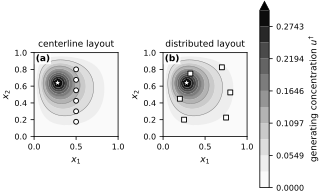

In [4]:
true_location = np.array([0.28, 0.64])
reflected_location = np.array([1.0 - true_location[0], true_location[1]])
noise_scale = 0.004
random_seed = 20260918

centerline_sensors = np.array(
    [
        [0.500, 0.175],
        [0.500, 0.300],
        [0.500, 0.425],
        [0.500, 0.550],
        [0.500, 0.675],
        [0.500, 0.800],
    ]
)
distributed_sensors = np.array(
    [
        [0.250, 0.200],
        [0.750, 0.225],
        [0.200, 0.450],
        [0.800, 0.525],
        [0.325, 0.750],
        [0.700, 0.825],
    ]
)
heldout_sensors = np.array(
    [
        [0.250, 0.325],
        [0.750, 0.400],
        [0.375, 0.825],
        [0.825, 0.700],
    ]
)
all_sensors = np.vstack(
    (centerline_sensors, distributed_sensors, heldout_sensors)
)

truth_segments = 160
truth_start = time.perf_counter()
truth_axis, truth_points, truth_factorization, truth_h = build_poisson_solver(
    truth_segments
)
truth_source = source_density(truth_points, true_location)[:, 0]
truth_interior = truth_factorization.solve(truth_source)
truth_sensor_values = truth_interior[
    sensor_dofs(all_sensors, truth_segments)
]
truth_seconds = time.perf_counter() - truth_start

rng = np.random.default_rng(random_seed)
shared_noise = noise_scale * rng.standard_normal(centerline_sensors.shape[0])
centerline_observations = truth_sensor_values[:6] + shared_noise
distributed_observations = truth_sensor_values[6:12] + shared_noise
heldout_observations = (
    truth_sensor_values[12:] + noise_scale * rng.standard_normal(heldout_sensors.shape[0])
)

full_axis = np.linspace(0.0, 1.0, truth_segments + 1)
truth_field = np.zeros((truth_segments + 1, truth_segments + 1))
truth_field[1:-1, 1:-1] = truth_interior.reshape(
    truth_segments - 1, truth_segments - 1
)

fig, axes = new_figure("full_landscape", ncols=2)
levels = np.linspace(0.0, truth_field.max(), 12)
for axis, sensors, title, marker in zip(
    axes,
    (centerline_sensors, distributed_sensors),
    ("centerline layout", "distributed layout"),
    ("o", "s"),
):
    filled = axis.contourf(
        full_axis,
        full_axis,
        truth_field.T,
        levels=levels,
        cmap="Greys",
        extend="max",
    )
    axis.contour(
        full_axis,
        full_axis,
        truth_field.T,
        levels=levels[2::2],
        colors="0.45",
        linewidths=0.45,
    )
    axis.scatter(
        sensors[:, 0],
        sensors[:, 1],
        marker=marker,
        s=24,
        facecolors="white",
        edgecolors="black",
        linewidths=0.9,
        zorder=3,
    )
    axis.scatter(
        *true_location,
        marker="*",
        s=70,
        facecolors="white",
        edgecolors="black",
        linewidths=0.9,
        zorder=4,
    )
    axis.set(
        xlabel="$x_1$",
        ylabel="$x_2$",
        title=title,
        xlim=(0.0, 1.0),
        ylim=(0.0, 1.0),
        aspect="equal",
    )

colorbar = fig.colorbar(filled, ax=axes, fraction=0.045, pad=0.03)
colorbar.set_label("generating concentration $u^{\\dagger}$")
label_panels(axes, boxed=True)
finalize_axes(axes, keep_box=True)
plt.show()


In [5]:
inference_segments = 40
setup_start = time.perf_counter()
inference_axis, inference_points, inference_factorization, inference_h = (
    build_poisson_solver(inference_segments)
)
inference_sensor_indices = sensor_dofs(all_sensors, inference_segments)
sensor_responses = build_sensor_responses(
    inference_factorization,
    inference_sensor_indices,
    inference_points.shape[0],
)
setup_seconds = time.perf_counter() - setup_start

coarse_truth_predictions = (
    sensor_responses @ source_density(inference_points, true_location)[:, 0]
)
maximum_discrepancy = np.max(
    np.abs(coarse_truth_predictions - truth_sensor_values)
)

display_book_table(
    ["quantity", "value"],
    [
        ("fine-grid unknowns", f"{truth_points.shape[0]:,}"),
        ("coarse-grid unknowns", f"{inference_points.shape[0]:,}"),
        ("calibration sensors per layout", "6"),
        ("held-out sensors", "4"),
        ("maximum sensor-space discrepancy", f"{maximum_discrepancy:.3e}"),
        ("discrepancy / noise standard deviation", f"{maximum_discrepancy / noise_scale:.3f}"),
    ],
    column_spec="lr",
)


quantity,value
fine-grid unknowns,"25,281"
coarse-grid unknowns,"1,521"
calibration sensors per layout,6
held-out sensors,4
maximum sensor-space discrepancy,1.771e-04
discrepancy / noise standard deviation,0.044


## Bayesian formulation

For layout $d$ and sensor $j$, the observation is

$$
Y_{d,j}=G_{h,d,j}(\boldsymbol{\theta})+\varepsilon_{d,j},
\qquad
\varepsilon_{d,j}\overset{\mathrm{iid}}{\sim}
\mathcal{N}(0,\sigma_{\mathrm{obs}}^2),
$$

where $\sigma_{\mathrm{obs}}=0.004$ is treated as known. The prior is continuous and uniform on $\Theta$:

$$
p_0(\boldsymbol{\theta})
=\frac{1}{0.7^2}\mathbf{1}_{\Theta}(\boldsymbol{\theta}).
$$

For the observed vector $\mathbf{y}_d\in\mathbb{R}^6$, the posterior density is

$$
p_d(\boldsymbol{\theta}\mid\mathbf{y}_d)
\propto
\exp\!\left[
-\frac{\|\mathbf{y}_d-\mathbf{G}_{h,d}(\boldsymbol{\theta})\|_2^2}
{2\sigma_{\mathrm{obs}}^2}
\right]
p_0(\boldsymbol{\theta}).
$$

Here $\mathbf{1}_{\Theta}$ is the indicator of the prior box. The parameter is two-dimensional, so deterministic tensor-product quadrature is practical. A $281\times281$ trapezoidal grid approximates posterior integrals; a nested $141\times141$ grid checks numerical stability. We also form a 90% highest-posterior-density (HPD) region from the normalized density. These are quadrature grids for a continuous posterior, not discrete parameter priors. MCMC diagnostics do not apply; the relevant checks are quadrature refinement, discretization error, posterior boundary mass, and the reflection identity developed below {cite:p}`stuart2010inverse`.


In [6]:
def trapezoidal_weights(values):
    spacing = values[1] - values[0]
    weights = np.full(values.size, spacing)
    weights[[0, -1]] *= 0.5
    return weights


def normalize_posterior(log_density, values):
    one_dimensional_weights = trapezoidal_weights(values)
    quadrature_weights = (
        one_dimensional_weights[:, None] * one_dimensional_weights[None, :]
    )
    log_normalizer = logsumexp(log_density + np.log(quadrature_weights))
    density = np.exp(log_density - log_normalizer)
    mass = density * quadrature_weights
    return density, mass


def weighted_quantile(values, masses, probability):
    return np.interp(probability, np.cumsum(masses), values)


def summarize_posterior(log_density, values):
    density, mass = normalize_posterior(log_density, values)
    marginal_x = mass.sum(axis=1)
    marginal_y = mass.sum(axis=0)
    mean = np.array((marginal_x @ values, marginal_y @ values))
    intervals = np.array(
        [
            [
                weighted_quantile(values, marginal_x, 0.05),
                weighted_quantile(values, marginal_x, 0.95),
            ],
            [
                weighted_quantile(values, marginal_y, 0.05),
                weighted_quantile(values, marginal_y, 0.95),
            ],
        ]
    )

    ordered = np.argsort(density.ravel())[::-1]
    ordered_mass = mass.ravel()[ordered]
    cutoff_index = np.searchsorted(np.cumsum(ordered_mass), 0.90)
    hpd_cutoff = density.ravel()[ordered[cutoff_index]]
    hpd_components = label(density >= hpd_cutoff)[1]

    xx, yy = np.meshgrid(values, values, indexing="ij")
    edge = (
        (xx <= values[0] + 0.02)
        | (xx >= values[-1] - 0.02)
        | (yy <= values[0] + 0.02)
        | (yy >= values[-1] - 0.02)
    )
    maximum_index = np.unravel_index(np.argmax(log_density), log_density.shape)
    mode = np.array((values[maximum_index[0]], values[maximum_index[1]]))
    return {
        "density": density,
        "mass": mass,
        "mean": mean,
        "intervals": intervals,
        "hpd_cutoff": hpd_cutoff,
        "hpd_components": hpd_components,
        "edge_mass": mass[edge].sum(),
        "left_mass": mass[values < 0.5, :].sum(),
        "mode": mode,
    }


candidate_values = np.linspace(0.15, 0.85, 281)
candidate_x, candidate_y = np.meshgrid(
    candidate_values, candidate_values, indexing="ij"
)
candidate_locations = np.column_stack(
    (candidate_x.ravel(), candidate_y.ravel())
)

posterior_start = time.perf_counter()
candidate_predictions = predict_candidates(
    inference_points, sensor_responses, candidate_locations
)
centerline_log_density = -0.5 * np.sum(
    (
        (candidate_predictions[:, :6] - centerline_observations)
        / noise_scale
    )
    ** 2,
    axis=1,
).reshape(candidate_values.size, candidate_values.size)
distributed_log_density = -0.5 * np.sum(
    (
        (candidate_predictions[:, 6:12] - distributed_observations)
        / noise_scale
    )
    ** 2,
    axis=1,
).reshape(candidate_values.size, candidate_values.size)

centerline_posterior = summarize_posterior(
    centerline_log_density, candidate_values
)
distributed_posterior = summarize_posterior(
    distributed_log_density, candidate_values
)

coarse_values = candidate_values[::2]
centerline_coarse = summarize_posterior(
    centerline_log_density[::2, ::2], coarse_values
)
distributed_coarse = summarize_posterior(
    distributed_log_density[::2, ::2], coarse_values
)
posterior_seconds = time.perf_counter() - posterior_start

centerline_prediction_grid = candidate_predictions[:, :6].reshape(
    candidate_values.size, candidate_values.size, 6
)
reflection_residual = np.max(
    np.abs(centerline_prediction_grid - centerline_prediction_grid[::-1, :, :])
)

left_index = np.unravel_index(
    np.argmax(
        np.where(
            candidate_x < 0.5,
            centerline_log_density,
            -np.inf,
        )
    ),
    centerline_log_density.shape,
)
right_index = np.unravel_index(
    np.argmax(
        np.where(
            candidate_x > 0.5,
            centerline_log_density,
            -np.inf,
        )
    ),
    centerline_log_density.shape,
)
centerline_modes = np.array(
    [
        [candidate_values[left_index[0]], candidate_values[left_index[1]]],
        [candidate_values[right_index[0]], candidate_values[right_index[1]]],
    ]
)


In [7]:
def interval_text(interval):
    return f"[{interval[0]:.3f}, {interval[1]:.3f}]"


display_book_table(
    ["layout", "quadrature-grid mode(s)", "left mass", "90% HPD pieces"],
    [
        (
            "centerline",
            "; ".join(
                f"({mode[0]:.3f}, {mode[1]:.3f})"
                for mode in centerline_modes
            ),
            f"{centerline_posterior['left_mass']:.3f}",
            str(centerline_posterior["hpd_components"]),
        ),
        (
            "distributed",
            f"({distributed_posterior['mode'][0]:.3f}, {distributed_posterior['mode'][1]:.3f})",
            f"{distributed_posterior['left_mass']:.3f}",
            str(distributed_posterior["hpd_components"]),
        ),
    ],
    column_spec="llrr",
)

display_book_table(
    ["layout", "mean theta_1 (90% interval)", "mean theta_2 (90% interval)"],
    [
        (
            "centerline",
            f"{centerline_posterior['mean'][0]:.3f} "
            + interval_text(centerline_posterior["intervals"][0]),
            f"{centerline_posterior['mean'][1]:.3f} "
            + interval_text(centerline_posterior["intervals"][1]),
        ),
        (
            "distributed",
            f"{distributed_posterior['mean'][0]:.3f} "
            + interval_text(distributed_posterior["intervals"][0]),
            f"{distributed_posterior['mean'][1]:.3f} "
            + interval_text(distributed_posterior["intervals"][1]),
        ),
    ],
    column_spec="lrr",
)

diagnostic_rows = []
for name, fine, coarse in (
    ("centerline", centerline_posterior, centerline_coarse),
    ("distributed", distributed_posterior, distributed_coarse),
):
    diagnostic_rows.append(
        (
            name,
            f"{np.max(np.abs(fine['mean'] - coarse['mean'])):.2e}",
            f"{np.max(np.abs(fine['intervals'] - coarse['intervals'])):.2e}",
            f"{fine['edge_mass']:.2e}",
        )
    )

display_book_table(
    ["layout", "max mean change", "max interval change", "edge mass"],
    diagnostic_rows,
    column_spec="lrrr",
)

display_book_table(
    ["calculation", "algorithmic work", "wall time"],
    [
        (
            "fine-grid data",
            f"1 factorization + 1 solve ({truth_points.shape[0]:,} unknowns)",
            f"{truth_seconds:.3f} s",
        ),
        (
            "coarse responses",
            f"1 factorization + {all_sensors.shape[0]} adjoint RHS "
            f"({inference_points.shape[0]:,} unknowns)",
            f"{setup_seconds:.3f} s",
        ),
        (
            "two posteriors",
            f"{candidate_locations.shape[0]:,} source locations",
            f"{posterior_seconds:.3f} s",
        ),
    ],
    column_spec="llr",
)

print(f"Maximum centerline reflection residual: {reflection_residual:.3e}")


layout,quadrature-grid mode(s),left mass,90% HPD pieces
centerline,"(0.280, 0.635); (0.720, 0.635)",0.500,2
distributed,"(0.277, 0.645)",1.000,1


layout,mean theta_1 (90% interval),mean theta_2 (90% interval)
centerline,"0.500 [0.274, 0.723]","0.635 [0.620, 0.648]"
distributed,"0.280 [0.263, 0.297]","0.644 [0.634, 0.652]"


layout,max mean change,max interval change,edge mass
centerline,1.07e-07,1.82e-03,4.53e-127
distributed,5.89e-10,1.71e-03,4.64e-91


calculation,algorithmic work,wall time
fine-grid data,"1 factorization + 1 solve (25,281 unknowns)",0.046 s
coarse responses,"1 factorization + 16 adjoint RHS (1,521 unknowns)",0.002 s
two posteriors,"78,961 source locations",1.521 s


Maximum centerline reflection residual: 2.220e-15


## Reflection ambiguity

Define the reflection map $R:\Theta\to\Theta$ by $R\boldsymbol{\theta}=(1-\theta_1,\theta_2)$. The square domain, zero boundary condition, Laplacian, and normalized source family are invariant under reflection about $x_1=1/2$. Uniqueness of the forward solution therefore gives

$$
u_{R\boldsymbol{\theta}}(x_1,x_2)
=u_{\boldsymbol{\theta}}(1-x_1,x_2).
$$

Every centerline sensor is fixed by this reflection, so

$$
\mathbf{G}_{h,\mathrm{center}}(R\boldsymbol{\theta})
=\mathbf{G}_{h,\mathrm{center}}(\boldsymbol{\theta}).
$$

The uniform prior is also reflection invariant. Hence

$$
p_{\mathrm{center}}(R\boldsymbol{\theta}\mid\mathbf{y})
=p_{\mathrm{center}}(\boldsymbol{\theta}\mid\mathbf{y})
$$

for every observed centerline data vector. Noise cannot distinguish the two reflected centers because they make exactly the same predictions. The distributed layout breaks this particular invariance, although this one example does not prove global identifiability or optimality. Formal sensor design selects locations using a stated utility or uncertainty criterion; the two layouts here are hand selected to expose the symmetry {cite:p}`alexanderian2021optimal`.


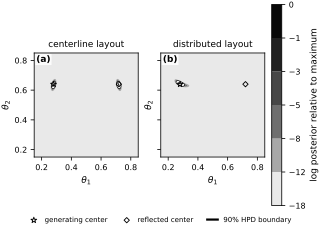

In [8]:
fig, axes = new_figure("full_standard", ncols=2, sharex=True, sharey=True)
relative_levels = np.array([-18.0, -12.0, -8.0, -5.0, -3.0, -1.0, 0.0])

for axis, log_density, posterior, title in zip(
    axes,
    (centerline_log_density, distributed_log_density),
    (centerline_posterior, distributed_posterior),
    ("centerline layout", "distributed layout"),
):
    relative_log_density = log_density - np.max(log_density)
    filled = axis.contourf(
        candidate_values,
        candidate_values,
        np.clip(relative_log_density, relative_levels[0], 0.0).T,
        levels=relative_levels,
        cmap="Greys",
    )
    contour = axis.contour(
        candidate_values,
        candidate_values,
        posterior["density"].T,
        levels=[posterior["hpd_cutoff"]],
        colors="white",
        linewidths=1.3,
    )
    contour.set_path_effects(
        [path_effects.Stroke(linewidth=2.5, foreground="black"), path_effects.Normal()]
    )
    axis.scatter(
        *true_location,
        marker="*",
        s=36,
        facecolors="none",
        edgecolors="black",
        linewidths=0.9,
        zorder=4,
        label="generating center",
    )
    axis.scatter(
        *reflected_location,
        marker="D",
        s=14,
        facecolors="none",
        edgecolors="black",
        linewidths=0.9,
        zorder=4,
        label="reflected center",
    )
    axis.set(
        xlabel="$\\theta_1$",
        ylabel="$\\theta_2$",
        title=title,
        xlim=(0.15, 0.85),
        ylim=(0.15, 0.85),
        aspect="equal",
    )

colorbar = fig.colorbar(filled, ax=axes, fraction=0.045, pad=0.03)
colorbar.set_label("log posterior relative to maximum")
hpd_handle = Line2D(
    [0], [0], color="black", linewidth=2.2, label="90% HPD boundary"
)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles + [hpd_handle],
    labels + ["90% HPD boundary"],
    loc="outside lower center",
    ncols=3,
    handlelength=1.5,
)
label_panels(axes, boxed=True)
finalize_axes(axes, keep_box=True)
plt.show()


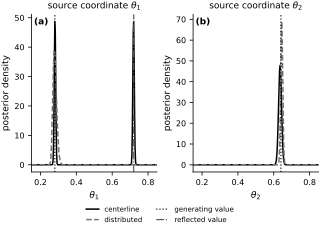

In [9]:
centerline_marginal_x = np.trapezoid(
    centerline_posterior["density"], candidate_values, axis=1
)
centerline_marginal_y = np.trapezoid(
    centerline_posterior["density"], candidate_values, axis=0
)
distributed_marginal_x = np.trapezoid(
    distributed_posterior["density"], candidate_values, axis=1
)
distributed_marginal_y = np.trapezoid(
    distributed_posterior["density"], candidate_values, axis=0
)

fig, axes = new_figure("full_standard", ncols=2)
for axis, centerline_marginal, distributed_marginal, coordinate in zip(
    axes,
    (centerline_marginal_x, centerline_marginal_y),
    (distributed_marginal_x, distributed_marginal_y),
    (1, 2),
):
    axis.plot(
        candidate_values,
        centerline_marginal,
        color="black",
        linestyle="-",
        label="centerline",
    )
    axis.plot(
        candidate_values,
        distributed_marginal,
        color="0.45",
        linestyle="--",
        label="distributed",
    )
    axis.axvline(
        true_location[coordinate - 1],
        color="black",
        linestyle=":",
        linewidth=1.2,
        label="generating value" if coordinate == 1 else None,
    )
    if coordinate == 1:
        axis.axvline(
            reflected_location[0],
            color="0.35",
            linestyle="-.",
            linewidth=1.2,
            label="reflected value",
        )
    axis.set(
        xlabel=rf"$\theta_{coordinate}$",
        ylabel="posterior density",
        xlim=(0.15, 0.85),
        title=rf"source coordinate $\theta_{coordinate}$",
    )

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="outside lower center",
    ncols=2,
    handlelength=1.8,
)
label_panels(axes)
finalize_axes(axes)
plt.show()


The centerline posterior assigns one half of its mass to each side of the symmetry line and has two disconnected 90% highest-posterior-density components. Its posterior mean $\mathbb{E}[\theta_1\mid\mathbf{y}]=0.5$ lies between the modes and is therefore a poor point summary. Both reflected modes must be reported.

For this noise realization, the distributed layout yields one connected 90% region near the generating center. The $281\times281$ and $141\times141$ quadrature summaries agree to the scale reported above, and negligible posterior mass lies along the edge of the prior box. These numerical checks support the displayed calculation; they do not validate the physical model.


## Held-out prediction

The posterior predictive distribution at four locations excluded from both calibrations gives a small predictive check. For a held-out sensor at $\mathbf{x}'$, its posterior predictive distribution is the Gaussian mixture

$$
p(\widetilde{y}\mid\mathbf{y}_d)
=\int_{\Theta}
\mathcal{N}\!\left(
\widetilde{y}\mid G_h(\boldsymbol{\theta};\mathbf{x}'),
\sigma_{\mathrm{obs}}^2
\right)
p_d(\boldsymbol{\theta}\mid\mathbf{y}_d)
\,d\boldsymbol{\theta}.
$$

Here $G_h(\boldsymbol{\theta};\mathbf{x}')$ denotes the coarse-grid concentration predicted at $\mathbf{x}'$. The 90% posterior predictive intervals (PI) below include both parameter uncertainty and fresh measurement noise. The mixture quantiles are evaluated deterministically from the quadrature weights.


In [10]:
def mixture_quantiles(posterior_mass, component_means, probabilities=(0.05, 0.5, 0.95)):
    flat_mass = posterior_mass.ravel()
    quantiles = np.empty((component_means.shape[1], len(probabilities)))
    for sensor_index in range(component_means.shape[1]):
        means = component_means[:, sensor_index]
        lower = means.min() - 7.0 * noise_scale
        upper = means.max() + 7.0 * noise_scale

        def mixture_cdf(value):
            return np.dot(flat_mass, ndtr((value - means) / noise_scale))

        for probability_index, probability in enumerate(probabilities):
            quantiles[sensor_index, probability_index] = brentq(
                lambda value: mixture_cdf(value) - probability,
                lower,
                upper,
            )
    return quantiles


heldout_candidate_predictions = candidate_predictions[:, 12:]
centerline_predictive = mixture_quantiles(
    centerline_posterior["mass"], heldout_candidate_predictions
)
distributed_predictive = mixture_quantiles(
    distributed_posterior["mass"], heldout_candidate_predictions
)

prediction_rows = []
for index, observation in enumerate(heldout_observations):
    prediction_rows.append(
        (
            f"H{index + 1}",
            f"{observation:.4f}",
            f"[{centerline_predictive[index, 0]:.4f}, "
            f"{centerline_predictive[index, 2]:.4f}]",
            f"[{distributed_predictive[index, 0]:.4f}, "
            f"{distributed_predictive[index, 2]:.4f}]",
        )
    )

display_book_table(
    ["sensor", "observed", "centerline 90% PI", "distributed 90% PI"],
    prediction_rows,
    column_spec="lrrr",
)

centerline_covered = np.sum(
    (heldout_observations >= centerline_predictive[:, 0])
    & (heldout_observations <= centerline_predictive[:, 2])
)
distributed_covered = np.sum(
    (heldout_observations >= distributed_predictive[:, 0])
    & (heldout_observations <= distributed_predictive[:, 2])
)
centerline_width = np.median(
    centerline_predictive[:, 2] - centerline_predictive[:, 0]
)
distributed_width = np.median(
    distributed_predictive[:, 2] - distributed_predictive[:, 0]
)

print(
    f"Held-out observations inside the 90% intervals: "
    f"centerline {centerline_covered}/4; distributed {distributed_covered}/4"
)
print(
    f"Median 90% predictive width: centerline {centerline_width:.4f}; "
    f"distributed {distributed_width:.4f}"
)


sensor,observed,centerline 90% PI,distributed 90% PI
H1,0.0692,"[0.0266, 0.0819]","[0.0643, 0.0799]"
H2,0.0385,"[0.0329, 0.1173]","[0.0299, 0.0447]"
H3,0.1120,"[0.0429, 0.1192]","[0.1074, 0.1229]"
H4,0.0270,"[0.0216, 0.1797]","[0.0196, 0.0335]"


Held-out observations inside the 90% intervals: centerline 4/4; distributed 4/4
Median 90% predictive width: centerline 0.0803; distributed 0.0151


All four held-out observations lie inside both sets of 90% intervals. Four observations are too few to assess predictive calibration and provide only a small consistency check. The centerline intervals are much wider at off-axis locations because the two reflected source modes predict different concentrations there. The distributed observations remove that particular ambiguity and narrow the predictive mixture.

## Scope

This example assumes that the steady diffusion equation, absorbing boundary, source shape, source strength, and noise scale are correct. It includes no advection, uncertain diffusivity, background contamination, correlated measurement error, or model-discrepancy term. It establishes an exact reflection non-identifiability for one sensor layout and demonstrates its removal for one realized distributed-layout data set. It does not establish that the distributed layout is optimal or that every source center is globally identifiable.

## Exercises

1. Prove the centerline identity $\mathbf{G}_{h,\mathrm{center}}(R\boldsymbol{\theta})=\mathbf{G}_{h,\mathrm{center}}(\boldsymbol{\theta})$. Then prove that any reflection-symmetric prior preserves equal posterior density at $\boldsymbol{\theta}$ and $R\boldsymbol{\theta}$.
2. Move only the uppermost centerline sensor from $(0.5,0.8)$ to $(0.6,0.8)$. Recompute the posterior and report the posterior odds $\Pr(\theta_1<0.5\mid\mathbf{y})/\Pr(\theta_1>0.5\mid\mathbf{y})$.
3. Treat the source strength as unknown by setting $Q=\exp(\alpha)$ and assigning $\alpha\sim\mathcal{N}(0,0.3^2)$. Compare the marginal intervals for $\boldsymbol{\theta}$ with those obtained when $Q=1$ is known.
4. Repeat the inference with $N=40$, $80$, and $120$ segments per coordinate. At each resolution, report the maximum sensor-space change relative to $\sigma_{\mathrm{obs}}$ and the changes in posterior means and 90% intervals.
5. Replace the forward equation by $-0.02\Delta u+(1,0)\mathbin{\cdot}\nabla u=s_{\boldsymbol{\theta}}$ with $u=0$ on $\partial D$, using first-order upwinding for the advective term. Determine whether reflection about $x_1=1/2$ still preserves centerline predictions and explain the result from the transformed PDE.
